# ecDNAInspector_cycle_selection
### This notebook includes all steps needed to go from raw cycle prediction files to a csv file with all calculated metrics and confidence assignments for each prediction.

In [4]:
import os
import numpy as np
import pandas as pd
from itertools import combinations
import ast

# note - the clustering module only works with numpy=1.24, so make sure this is the version installed!

%run 'ecDNAInspector_functions.ipynb'
print("ecDNAInspector functions loaded!")

ecDNAInspector functions loaded!


## Define paths and constants.
#### Some notes:
- **Make sure to confirm the formats of your text files with the provided sample files!** 
- If you are starting from raw cycle prediction files from AmpliconArchitect/CoRAL, you can proceed directly with cycle file conversion. Otherwise, you will need to convert the cycle files yourself to the standard format and disable the cycle processing step (see comment below).
- Confirm that your input gene files and blacklist files match the assembly you used to align your sequencing data. See the github for links to suggested gene files.
- For the gene file, you can use either a standard Cosmic gene file (for cancer genes) or a standard gencode annotation file (for all genes). See github for links to suggested gene files but confirm the format matches the provided sample files! You can directly use the sample files if you are using hg38 alignment.
- **The quality of your structural variant calls matters!** The confidence assignment of each ecDNA is extremely depending on your selection of SVs, so the quality of your "ground truth" SV list is very important. We recommend using the consensus of at least two different callers to produce a high quality list (see the ecDNAInspector manuscript for additional details; our original study used the consensus of four callers.)
- **Your choice of input buffers, threshholds, and parameters matters!** Please read the ecDNAInspector manuscript for more information and the github page for user suggestions for each metric. We recommend trying multiple combinations of metrics to assess how decisions affect output and may need to be tailored to your specific dataset.

In [5]:
# File inputs and conversions
input_cycles_path = 'final_tool_testing/ic_raw_cycle_files/'
amplicon_info = 'final_tool_testing/ic_amplicon_info.csv'
SV_path = 'final_tool_testing/ic_sv_calls.txt'
processed_cycle_files = 'final_tool_testing/ic_processed_cycle_files/'
bed_files_path = 'final_tool_testing/ic_bed_files/'
# if you are using the Cosmic gene file, set the "gene_list" parameter below equal to "Cosmic". If you are using the reference gene file, set it to "Reference".
gene_file = 'final_tool_testing/Cosmic_CancerGeneCensus_v98_GRCh37.tsv'
blacklist_file = 'final_tool_testing/encode_blacklist_regions.bed'

# Data table inputs
cycle_level_data_table = 'final_tool_testing/ic_cycle_data_table.csv'
cycle_level_data_clustered_table = 'final_tool_testing/ic_cycle_data_clustered_table.csv'
cycle_level_data_w_conf_table = 'final_tool_testing/ic_cycle_data_w_conf.csv'

# Analysis specifications
cycle_type_to_include = "all"

# Buffers, threshholds, and parameters
gene_list = "Cosmic" # either "Cosmic" or "Reference". Update the gene_file path accordingly!
be_overlap_buffer = 100 # Max distance between breakends to be overlapping
SV_in_range_buffer = 100 # Max distance between SV and BE to be overlapping
blacklist_buffer = 100 # Max distance between BE and blacklist region for BE to be considered included
small_del_len = 2000 # Max length of deletion to be excluded from SV validations
gene_inclusion_prop_buffer = 1.0 # proportion of total gene size that must be present in cycle for full gene to be considered included
copy_count_threshold = 4.0 # Min copy count to include single cycle
duplicate_buffer = 100 # Max distance between matched ends of paired ends for paired ends to be considered duplicates.
min_clusters = 3 # Min number of clusters to try. Minimum 3 recommended.
max_clusters = 5 # Max number of clusters to try
cluster_num_resamples = 1000 # number of resamples for clustering
cluster_resample_prop = 0.8 # proportion of samples to resample
n_init = 10 # number of KMeans runs with different centroid seeds. Higher --> slower, but likely better clustering

## Convert all cycle files.
#### If you did not use AmpliconArchitect/CoRAL to produce your cycle prediction files, please skip these lines. Ensure that your manually converted cycle files are in the "processed_cycle_files" folder defined above.

In [6]:
sample_amp_dict = parse_amp_info_file_for_sample_amp_dict(amplicon_info)
convert_cycle_file_set(sample_amp_dict, input_cycles_path, processed_cycle_files, copy_count_threshold, cycle_type_to_include)

print("cycle files converted!")

cycle files converted!


## Load blacklist, SV, and gene data.

In [7]:
blacklist_dict = parse_blacklist_file_for_blacklist_dict(blacklist_file)

print("blacklist dictionary constructed!")

svs_dict = parse_SV_file_for_SVs(SV_path)

print("SVs dictionary constructed!")

if gene_list == "Cosmic":
    cosmic_genes_dict = parse_cosmic_for_gene_dict(gene_file)
    print("Cosmic genes dictionary constructed!")

if gene_list == "Reference":
    ref_genes_dict = parse_reference_for_genome_dict(gene_file)
    print("Reference genes dictionary constructed!")

blacklist dictionary constructed!
SVs dictionary constructed!
Cosmic genes dictionary constructed!


## Calculate cycle metrics.

In [26]:
output_file_data = [["Sample", "Amplicon", "Cycle", "Cycle Type", "Cycle Size (bp)", "Cycle Breakpoint Count",
                         "Cycle Chromosome Count", "Cycle Regions List", "Cycle Paired Ends List",
                         "Cycle TPR", "Cycle TP BEs", "Cycle FPR", "Cycle FP BEs", "Cycle PFNR", "Cycle PFN BEs", 
                         "Cycle MEB", "Cycle Mapping Error Breakends", "Cycle Unmappable Reasons", "Small Deletions Count", "Cycle Genes Info", "Cycle Genes List"]]

# iterate over every sample, amp, cycle
for sample in sample_amp_dict:
    print("Working on sample: " + str(sample))
    for amp in sample_amp_dict[sample]:
        cycle_file = processed_cycle_files + sample + "_processed_amplicon" + amp + "_cycles.txt"
        cycle_nums = parse_cycle_file_for_cycle_nums(cycle_file)
        for cycle in cycle_nums:
            cycle_type = parse_cycle_file_for_cycle_type(cycle_file, cycle)
            cycle_regions_dict = parse_cycle_file_for_cycle_region_dict(cycle_file, cycle)
            cycle_regions_list = parse_cycle_file_for_cycle_region_list(cycle_file, cycle)
            cycle_paired_ends = parse_cycle_file_for_cycle_paired_ends_list(cycle_file, cycle)
            cycle_size = calc_cycle_size(cycle_regions_list)
            cycle_num_bps = calc_cycle_num_breakpoints(cycle_paired_ends)
            cycle_num_chroms = calc_cycle_num_chroms(cycle_regions_list)
            cycle_TPR, TP_list, cycle_FPR, FP_list, small_del_removed = calc_TPR_and_FPR(cycle_paired_ends,
                                                                                              svs_dict, sample,
                                                                                              SV_in_range_buffer,
                                                                                              small_del_len)
            cycle_PFNR, PFN_list = calc_PFNR(cycle_paired_ends, small_del_len, bed_files_path, sample,
                                                   svs_dict, SV_in_range_buffer, TP_list, copy_count_threshold)
            cycle_MEB, cycle_mapping_errors, cycle_unmappable_reasons = calc_mapping_errors(cycle_paired_ends, blacklist_dict,
                                                                       blacklist_buffer)
            if gene_list == "Cosmic":
                cycle_genes_dict, cycle_genes_list = parse_cosmic_dict_for_genes_in_cycle(cycle_regions_dict, cosmic_genes_dict, gene_inclusion_prop_buffer)
            if gene_list == "Reference":
                cycle_genes_dict, cycle_genes_list = parse_genome_dict_for_features_in_cycle(cycle_regions_dict, ref_genes_dict, gene_inclusion_prop_buffer)
            cycle_info_list = [sample, amp, cycle, cycle_type, cycle_size, cycle_num_bps, cycle_num_chroms,
                               cycle_regions_list, cycle_paired_ends, cycle_TPR, TP_list, cycle_FPR,
                               FP_list, cycle_PFNR, PFN_list, cycle_MEB, cycle_mapping_errors, cycle_unmappable_reasons, small_del_removed, 
                               cycle_genes_dict, cycle_genes_list]
            output_file_data.append(cycle_info_list)
            
print("metric calculations complete")

Working on sample: CURTIS_H000380_T01_01_WG01
Working on sample: CURTIS_H000381_T01_01_WG01
Working on sample: CURTIS_H000382_T01_01_WG01
Working on sample: CURTIS_H000386_T01_01_WG01
Working on sample: CURTIS_H000387_T01_01_WG01
Working on sample: CURTIS_H000390_T01_01_WG01
Working on sample: CURTIS_H000391_T01_01_WG01
Working on sample: CURTIS_H000392_T01_01_WG01
Working on sample: CURTIS_H000393_T01_01_WG01
Working on sample: CURTIS_H000394_T01_01_WG01
Working on sample: CURTIS_H000396_T01_01_WG01
Working on sample: CURTIS_H000399_T01_01_WG01
Working on sample: CURTIS_H000400_T01_01_WG01
Working on sample: CURTIS_H000402_T01_01_WG01
Working on sample: CURTIS_H000405_T01_01_WG01
Working on sample: CURTIS_H000406_T01_01_WG01
Working on sample: CURTIS_H000407_T01_01_WG01
Working on sample: CURTIS_H000409_T01_01_WG01
Working on sample: CURTIS_H000412_T01_01_WG01
Working on sample: CURTIS_H000414_T01_01_WG01
Working on sample: CURTIS_H000415_T01_01_WG01
Working on sample: CURTIS_H000416_

## Save cycle metric data.

In [27]:
# write data to csv file
with open(cycle_level_data_table, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerows(output_file_data)
    
# convert csv back to dataframe
    
cohort_df = pd.read_csv(cycle_level_data_table)

# update dataframe with extreme size (ESB) boolean information

# The cohort percentiles below and above which (respective) cycle size should be labeled as "extreme". 
# We recommend adjusting these cutoffs according to the distribution of your dataset.
esb_percentiles = (0.1, 0.9) 

lower_size_bound = cohort_df["Cycle Size (bp)"].quantile(esb_percentiles[0])
upper_size_bound = cohort_df["Cycle Size (bp)"].quantile(esb_percentiles[1])

cohort_df["Cycle ESB"] = ((cohort_df["Cycle Size (bp)"] < lower_size_bound) | 
                           (cohort_df["Cycle Size (bp)"] > upper_size_bound)).astype(int)

# re-write data to csv file so ESB can be included in clustering visualization

cohort_df.to_csv(cycle_level_data_table, index=False)

## Check basic metrics of cohort.

In [28]:
cohort_df = pd.read_csv(cycle_level_data_table)

In [48]:
total_samples = len(cohort_df["Sample"].value_counts())
total_cycles = len(cohort_df)

In [49]:
print("Total samples: " + str(total_samples))
print("Total cycles: " + str(total_cycles))

Total samples: 231
Total cycles: 1012


## Cluster cycles.

In [33]:
features = ["Cycle TPR", "Cycle FPR", "Cycle PFNR", "Cycle MEB"]
cluster_with_consensus(cycle_level_data_table, cycle_level_data_clustered_table, features, min_clusters, max_clusters, cluster_num_resamples, cluster_resample_prop, n_init)

Total cycles eligible for clustering: 981


In [34]:
cohort_w_clust_df = pd.read_csv(cycle_level_data_clustered_table)

### Modify or add any features.

In [37]:
cohort_w_clust_df["Cycle Type Boolean"] = (cohort_w_clust_df["Cycle Type"] == "circular").astype(int)
cohort_w_clust_df["Cycle MEB"] = cohort_w_clust_df["Cycle MEB"].astype(int)

### Reorganize cluster names/order for visualization.

In [ ]:
# Reorganize the order of the cluster assignment numbers if desired. Otherwise, commment out line!
#cohort_w_clust_df['Cluster'] = cohort_w_clust_df['Cycle Cluster Assignment'].replace({0: 2, 1: 1, 2: 0})
cohort_w_clust_df['Cluster'] = cohort_w_clust_df['Cycle Cluster Assignment']
cohort_w_clust_df = cohort_w_clust_df.drop(columns=['Cycle Cluster Assignment'])
cohort_w_clust_df = cohort_w_clust_df.rename(columns={"Cluster": "Cycle Cluster Assignment"})

### Visualize clusters.

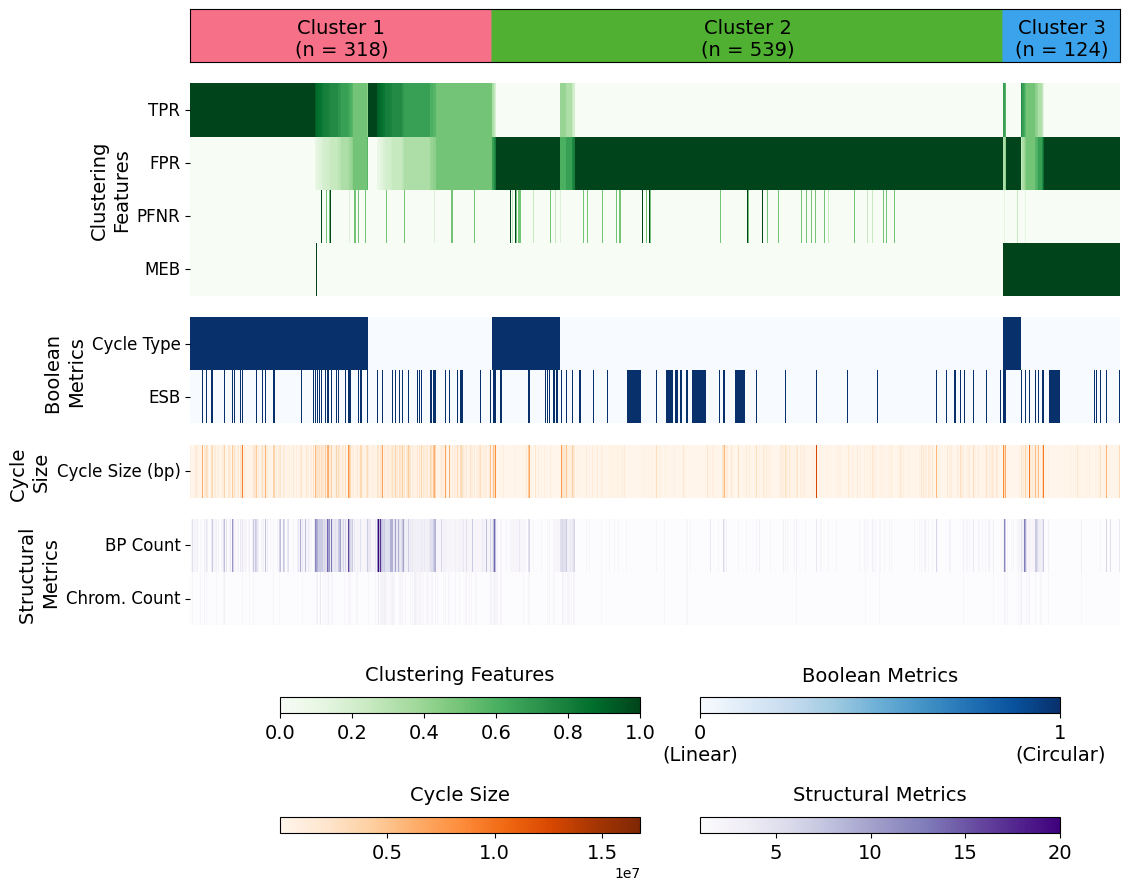

In [38]:
clustering_features = ["Cycle TPR", "Cycle FPR", "Cycle PFNR", "Cycle MEB"]
boolean_metrics = ["Cycle Type Boolean", "Cycle ESB"]
size_metric = ["Cycle Size (bp)"]
structural_metrics = ["Cycle Breakpoint Count", "Cycle Chromosome Count"]

cluster_feature_labels = ["TPR", "FPR", "PFNR", "MEB"]
boolean_metric_labels = ["Cycle Type", "ESB"]
size_metric_labels = ["Cycle Size (bp)"]
structural_metric_labels = ["BP Count", "Chrom. Count"]

sorting_features = ['Cycle Cluster Assignment', 'Cycle Type Boolean', 'Cycle TPR']
sorting_features_dir = [True, False, False]

plot_separated_clustering_heatmap(cohort_w_clust_df, 
                                  clustering_features, boolean_metrics, size_metric, structural_metrics, 
                                  cluster_feature_labels, boolean_metric_labels, size_metric_labels, structural_metric_labels,
                                  sorting_features, sorting_features_dir)

## Assign cycle confidence groups.

### Option 1: Confidence assignment by cluster.
##### Run this cell if you want to assign confidence purely by cluster

In [ ]:
# replace hc_cluster with your cluster(s) of high confidence cycles
hc_clusters = ['0']

# replace mc_cluster with your cluster of medium confidence cycles (if clearly distinguishable)
mc_clusters = ['1']

# replace lc_cluster with your cluster of low confidence cycles (if clearly distinguishable)
lc_clusters = ['2']

def assign_confidence_by_cluster(cluster):
    if cluster in hc_clusters:
        return "high"
    elif cluster in mc_clusters:
        return "medium"
    elif cluster in lc_clusters:
        return "low"

cohort_w_clust_df["Confidence"] = cohort_w_clust_df["Cycle Cluster Assignment"].apply(assign_confidence_by_cluster)
cohort_w_clust_df.to_csv(cycle_level_data_w_conf_table, index=False)

### Option 2: Confidence assignment by filtering.
##### Run this cell if you want additional filtering/selection for the cycles. Please see the ecDNAInspector manuscript and github page for more suggestions on setting threshholds and weights. **Users are recommended to try multiple combinations of values to assess impact on their cohort.**

In [40]:
# define TPR and FNR thresholds

TPR_threshold = 0.5
PFNR_threshold = 0.5

# define metric scores for threshold ranges. Lower scores indicate a higher confidence prediction.
# For TPR/FNR, these are the scores when: [TPR/FNR=0, TPR/FNR<threshold, TPR/FNR=>threshold, TPR/FNR=1]
# For MEB/ESB, these are the scores when: [MEB/ESB=0, MEB/ESB=1]
TPR_scores = [1.5, 1.0, 0.5, 0]
PFNR_scores = [0, 0.5, 1.0, 1.5]
MEB_scores = [0, 0.75]
ESB_scores = [0, 0.75]

# determine weights for the metrics. Set the weight equal to 0 if you want to exclude a metric. 

weights = {"TPR": 1, "MEB": 0.75, "ESB": 0.5, "PFNR": 0.25}

# define the total score thresholds for low, medium, and high confidence
# the format is: [high/medium threshold, medium/low threshold]
# being below the 0th entry indicates high confidence
# above the 1st entry indicates low confidence
# between is middle confidence
total_score_thresholds = [1, 2]

# It is recommended to use the default four selection, but you can remove any you don't want to include by setting it's weight to 0.
selection_values = ["Cycle TPR", "Cycle MEB", "Cycle ESB", "Cycle PFNR"]

cohort_w_conf_df = post_clustering_hierarchical_selection(cohort_w_clust_df, selection_values, 
                                                          TPR_threshold, PFNR_threshold, 
                                                          TPR_scores, PFNR_scores, MEB_scores, ESB_scores, 
                                                          total_score_thresholds, weights)

cohort_w_conf_df.to_csv(cycle_level_data_w_conf_table, index=False)

Total cycles with complete selection information: 981
Total high confidence cycles: 312
Total medium confidence cycles: 574
Total low confidence cycles: 95


## OPTIONAL: Intra-sample similarity filtering.
#### Some tools produce multiple cycles per sample that are highly similar, but may not represent genuinely unique ecDNA species. 
#### Run these cells if you wish to filter out these "copies", keeping only the highest-confidence version per sample.

In [ ]:
# maximum similarity two cycles from the same sample can have and be maintained after filtering.
threshold_value = 0.2

# path to file to store post-intra-sample-similarity filtering results.
intrasample_filt_cycle_level_data_w_conf_table = 'final_tool_testing/ic_intrasample_filt_cycle_data_w_conf.csv'

### Calculate intra-sample Jaccard indices (to assess similarity).

In [50]:
intra_sample_jaccards_results = []

for sample, group in cohort_df.groupby('Sample'):
    print(sample)
    pairs = list(combinations(group.itertuples(index=False), 2))
    
    for (row1, row2) in pairs:
        row1_cycle_regions = convert_cycle_regions_list_to_dict(ast.literal_eval(row1._asdict()['_7']))
        row2_cycle_regions = convert_cycle_regions_list_to_dict(ast.literal_eval(row2._asdict()['_7']))
        jaccard = calc_bp_jaccard(row1_cycle_regions, row2_cycle_regions)
        
        intra_sample_jaccards_results.append({
            'Sample': sample,
            'Amplicon1': row1.Amplicon,
            'Cycle1': row1.Cycle,
            'Amplicon2': row2.Amplicon,
            'Cycle2': row2.Cycle,
            'Jaccard': jaccard
        })

intrasample_jaccards_df = pd.DataFrame(intra_sample_jaccards_results)

CURTIS_H000381_T01_01_WG01
CURTIS_H000382_T01_01_WG01
CURTIS_H000387_T01_01_WG01
CURTIS_H000390_T01_01_WG01
CURTIS_H000392_T01_01_WG01
CURTIS_H000394_T01_01_WG01
CURTIS_H000396_T01_01_WG01
CURTIS_H000400_T01_01_WG01
CURTIS_H000402_T01_01_WG01
CURTIS_H000405_T01_01_WG01
CURTIS_H000407_T01_01_WG01
CURTIS_H000409_T01_01_WG01
CURTIS_H000412_T01_01_WG01
CURTIS_H000414_T01_01_WG01
CURTIS_H000415_T01_01_WG01
CURTIS_H000416_T01_01_WG01
CURTIS_H000427_T01_01_WG01
CURTIS_H000429_T01_01_WG01
CURTIS_H000432_T01_01_WG01
CURTIS_H000438_T01_01_WG01
CURTIS_H000443_T01_01_WG01
CURTIS_H000452_T01_01_WG01
CURTIS_H000454_T01_01_WG01
CURTIS_H000463_T01_01_WG01
CURTIS_H000472_T01_01_WG01
CURTIS_H000477_T01_01_WG01
CURTIS_H000485_T01_01_WG01
CURTIS_H000487_T01_01_WG01
CURTIS_H000489_T01_01_WG01
CURTIS_H000497_T01_01_WG01
CURTIS_H000498_T01_01_WG01
CURTIS_H000500_T01_01_WG01
CURTIS_H000501_T01_01_WG01
CURTIS_H000502_T01_01_WG01
CURTIS_H000505_T01_01_WG01
CURTIS_H000506_T01_01_WG01
CURTIS_H000511_T01_01_WG01
C

### Filter out intra-sample cycles with similarity exceeding the defined threshold.

In [51]:
intrasample_to_filter_df = intrasample_jaccards_df[intrasample_jaccards_df["Jaccard"] > threshold_value]

def filter_sample(sample_df, threshold_value):
    to_remove = []

    # for each unique sample, pull the pairwise comparisons with a Jaccard > threshold
    sample_name = sample_df['Sample'].iloc[0]
    sample_pairs = intrasample_to_filter_df[intrasample_to_filter_df['Sample'] == sample_name]

    for _, pair in sample_pairs.iterrows():
        
        amplicon_1, cycle_1 = pair['Amplicon1'], pair['Cycle1']
        amplicon_2, cycle_2 = pair['Amplicon2'], pair['Cycle2']
        
        pair_rows_1 = sample_df[(sample_df['Amplicon'] == amplicon_1) & 
                               (sample_df['Cycle'] == cycle_1)]
        pair_rows_2 = sample_df[(sample_df['Amplicon'] == amplicon_2) & 
                                 (sample_df['Cycle'] == cycle_2)]

        if not pair_rows_1.empty and not pair_rows_2.empty:
            
            # remove the cycle with the lower TPR
            tpr_1, tpr_2 = pair_rows_1['Cycle TPR'].iloc[0], pair_rows_2['Cycle TPR'].iloc[0]
            if tpr_1 > tpr_2:
                to_remove.append(pair_rows_2)
            else:
                to_remove.append(pair_rows_1)
    
    for rows in to_remove:
        sample_df = sample_df[~sample_df.index.isin(rows.index)]
    
    return sample_df

intrasample_filtered_cycle_data_df = pd.concat([filter_sample(sample_df, threshold_value) 
                                                for _, sample_df in cohort_w_conf_df.groupby('Sample')])

In [52]:
print("Total remaining cycles after intra-sample filtering: " + str(len(intrasample_filtered_cycle_data_df)))
print("Total high confidence cycles: " + str(len(intrasample_filtered_cycle_data_df[intrasample_filtered_cycle_data_df["Confidence"] == "high"])))
print("Total medium confidence cycles: " + str(len(intrasample_filtered_cycle_data_df[intrasample_filtered_cycle_data_df["Confidence"] == "medium"])))
print("Total low confidence cycles: " + str(len(intrasample_filtered_cycle_data_df[intrasample_filtered_cycle_data_df["Confidence"] == "low"])))

Total remaining cycles after intra-sample filtering: 783
Total high confidence cycles: 250
Total medium confidence cycles: 460
Total low confidence cycles: 73


### Visualize post-intra-sample-filtering cluster results.

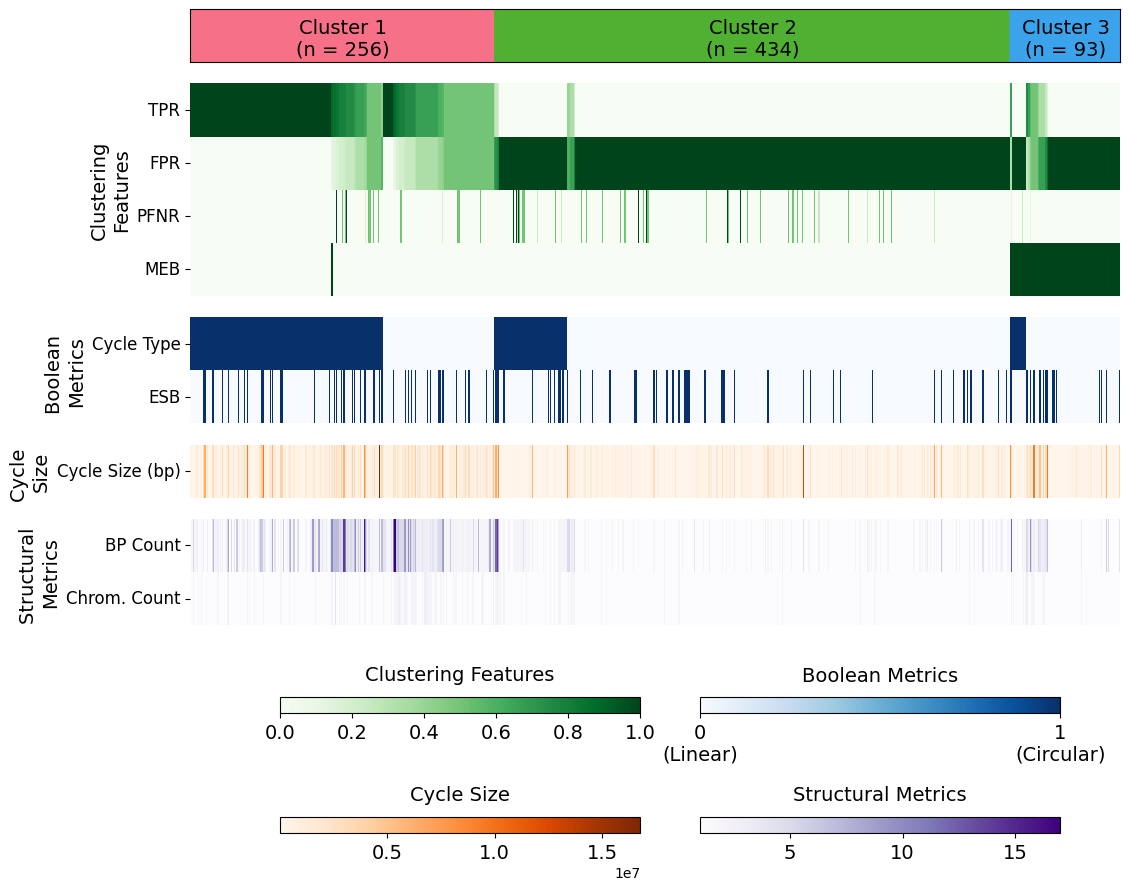

In [53]:
plot_separated_clustering_heatmap(intrasample_filtered_cycle_data_df, 
                                  clustering_features, boolean_metrics, size_metric, structural_metrics, 
                                  cluster_feature_labels, boolean_metric_labels, size_metric_labels, structural_metric_labels,
                                  sorting_features, sorting_features_dir)

### Save post-intra-sample-filtering data.

In [54]:
intrasample_filtered_cycle_data_df.to_csv(intrasample_filt_cycle_level_data_w_conf_table, index=False)